In [1]:
import torch
import torch.nn as nn
import numpy as np

from tqdm import tqdm

device = 'cuda' if torch.cuda.is_available() else "cpu"
print(device)



from IPython.display import clear_output
import matplotlib.pyplot as plt

cuda


In [3]:
import gymnasium as gym
from gymnasium.vector import AsyncVectorEnv

# Factory function to create one environment
def make_env():
    def _init():
        return gym.make("Ant-v4", exclude_current_positions_from_observation=False)
    return _init

# Create a list of 128 env constructors
num_envs = 128
env_fns = [make_env() for _ in range(num_envs)]

# Create vectorized environment
env = AsyncVectorEnv(env_fns)

# Reset all environments

env.state_dim = env.single_observation_space.shape[0]
env.action_dim = env.single_action_space.shape[0]

/home/nazim/.local/lib/python3.10/site-packages/gymnasium/envs/registration.py:517: DeprecationWarning: WARN: The environment Ant-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


In [3]:
# observations, infos = env.reset()

# for _ in tqdm(range(200)):
#     actions = env.action_space.sample()
#     observations, rewards, terminations, truncations, infos = env.step(actions)

#     # Optional: reset terminated/truncated envs
#     # if np.any(terminations) or np.any(truncations):
#     #     env.reset_done(terminations | truncations)s

# # env.close()

In [4]:
def compute_gae_parallel(dones, rewards, values, next_values, gamma=0.99, lambda_=0.95):
    assert (
        dones.shape == rewards.shape == values.shape == next_values.shape
    ), "All inputs must have the same shape (num_envs, sequence_length)."

    num_envs, seq_len = dones.shape
    advantages = torch.zeros_like(rewards, dtype=torch.float32)
    returns = torch.zeros_like(rewards, dtype=torch.float32)
    last_advantage = torch.zeros(num_envs, dtype=torch.float32)
    last_return = torch.zeros(num_envs, dtype=torch.float32)

    for t in reversed(range(seq_len)):
        mask = 1.0 - dones[:, t]
        last_value = next_values[:, t] * mask
        last_advantage = last_advantage * mask
        last_return = last_return * mask

        delta = rewards[:, t] + gamma * last_value - values[:, t]
        last_advantage = delta + gamma * lambda_ * last_advantage
        last_return = rewards[:, t] + gamma * last_return

        advantages[:, t] = last_advantage
        returns[:, t] = last_return

    return advantages, returns


def post_process(action):
    # return torch.tanh(action)
    # return action
    return torch.clip(action, -1, 1)



def collect_trajectories(env, z, model, n_steps, reward_generator, num_random_steps=0, base_z=None, target_model=None):

    # state_dim, action_dim = env.single_observation_space.shape[0], env.single_action_space.shape[0]
    state_dim, action_dim = env.state_dim, env.action_dim
    
    states = torch.zeros((env.num_envs, n_steps, state_dim), dtype=torch.float32)
    zs = torch.zeros((env.num_envs, n_steps, 128), dtype=torch.float32)
    actions = torch.zeros((env.num_envs, n_steps, action_dim), dtype=torch.float32)
    rewards = torch.zeros((env.num_envs, n_steps), dtype=torch.float32)
    log_ps = torch.zeros((env.num_envs, n_steps), dtype=torch.float32)
    state_values = torch.zeros((env.num_envs, n_steps), dtype=torch.float32)
    dones = torch.zeros((env.num_envs, n_steps), dtype=torch.float32)
    
    healthy = torch.full((env.num_envs,), fill_value=True)

    random_states = torch.zeros((env.num_envs, num_random_steps, state_dim), dtype=torch.float32)
    random_actions = torch.zeros((env.num_envs, num_random_steps, action_dim), dtype=torch.float32)
    
    state, _ = env.reset()
    state = torch.tensor(state).float()
    
    # tensor([-2.2573,  0.2734])
    # state = torch.tensor([[-2.2573,  0.2734, 0., 0.]]).repeat(env.num_envs, 1)
    
    total_reward = 0
    step_count = 0
    
    # Just to get the dist:
    state = state.to(device)
    with torch.no_grad():
        _, _, _, dist, _ = model(state, z)
    
    rollout = []
    
    # for s in tqdm(range(n_steps + num_random_steps)):
    for s in range(n_steps + num_random_steps):
        # state = torch.tensor(state).to(device)
        state = state.to(device)
        
        if s < n_steps:
            with torch.no_grad():
                
                
                
                if (state.isnan() | (state < -100) | (state > 100)).any():
                    # print((state.isnan().any(dim=1) * 1.).argmax())
                    non_healthy_idx = (state.isnan() | (state < -100) | (state > 100)).any(dim=1)
                    non_healthy_idx = non_healthy_idx.cpu()
                    healthy[non_healthy_idx] = False
                    # print(healthy)
                    state[~healthy] = 0

                    
                action, log_p, state_value, dist, entropy = model(state, z)
                
                # if base_z is None:
                #     action, log_p, state_value, dist, entropy = model(state, z)
                # else:
                #     if s < (EPISODE_LENGTH): # Use the previous policy to traverse the first half of the trajectory
                #         action, log_p, state_value, dist, entropy = target_model(state, base_z)
                #         action, log_p, state_value, dist, entropy = model(state, z, action=action)
                #     else:
                #         action, log_p, state_value, dist, entropy = model(state, z)
                        
                
                        
                
            next_state, reward, terminated, truncated, _ = env.step(post_process(action).tolist())
            done = terminated * truncated
            
            next_state = torch.tensor(next_state).float()
            reward = torch.tensor(reward)
            done = torch.tensor(done)
            

            # print(state[..., :2].shape, z.shape)
            # gm_reward = reward_generator.get_reward(state[..., :2], z)
            # gm_reward = state[..., 0].cpu()
            # gm_reward = torch.zeros((env.num_envs,))
            gm_reward = reward
            
            states[:, s] = state
            zs[:, s] = z.squeeze(-1)
            actions[:, s] = action
            rewards[:, s] = gm_reward.reshape(-1)
            log_ps[:, s] = log_p
            state_values[:, s] = state_value.reshape(-1)
            dones[:, s] = done
        
        
        else: # Increase the standard deviation:
            # print(s)
            dist.scale = torch.exp(torch.full_like(dist.scale, fill_value=model.action_std**2))
            random_action = dist.sample()
            action = random_action
            next_state, reward, terminated, truncated, _ = env.step(post_process(action))
            
            random_states[:, s - n_steps] = state
            random_actions[:, s - n_steps] = action
            
        
        
        # rollout.append((
        #     np.array(env.state.pipeline_state.x.pos),
        #     np.array(env.state.pipeline_state.x.rot),
        #     post_process(action)
        # ))
        
        state = next_state
        
        # print(env.state.pipeline_state.x.pos[:, 0, 0], env.state.pipeline_state.x.pos[:, 0, 1])
            
        

    
    critic_x = torch.concatenate((next_state, z.cpu()), dim=-1).to(device)
    next_value = model.critic(critic_x).cpu()
    next_state_values = torch.concatenate((state_values[:, 1:], next_value), dim=-1)
    
    advantages, returns = compute_gae_parallel(dones, rewards, state_values, next_state_values)
    
    
    
    
            
    trajectories = {
        # "descriptors": condition_descriptor.unsqueeze(1).repeat(1, n_steps, 1).reshape(-1, BEHAVIOR_DIM**2),
        "states" :  states.reshape(-1, state_dim).detach().cpu(),
        "zs" :  zs.reshape(-1, 128).detach().cpu(),
        "actions" : actions.reshape(-1, action_dim).detach().cpu(),
        "rewards" : rewards.reshape(-1).detach().cpu(),
        "dones" : dones.reshape(-1).detach().cpu(),
        "log_ps" : log_ps.reshape(-1).detach().cpu(),
        "state_values": state_values.reshape(-1).detach().cpu(),
        "next_state_values": next_state_values.reshape(-1).detach().cpu(),
        "returns" : returns.reshape(-1).detach().cpu(),
        "advantages" : advantages.reshape(-1).detach().cpu(),
    }
    
    
    # Replace unhealthy trajectories with healthy trajectories:
    healthy_idx = healthy.int().argmax()
    for i in (~healthy_idx).nonzero().flatten():
        for key in trajectories:
            trajectories[key][i*200:(i+1)*200] = trajectories[key][healthy_idx*200:(healthy_idx+1)*200]
    
    
    
    return trajectories, (random_states, random_actions)


# trajectories = collect_trajectories(env, model, n_steps=128)

# for key in trajectories:
#     print(key, trajectories[key].shape)

def shufffle_trajectory(trajectories):
    length = trajectories['states'].shape[0]
    permutation = torch.randperm(length)

    shuffled_trajectories = {key: tensor[permutation] for key, tensor in trajectories.items()}
    return shuffled_trajectories




In [5]:

def ppo_optimization(reward_generator, trajectories, model, optimizer, epochs, batch_size):
    
    model.train()
    
    traj_states = trajectories["states"]
    traj_z = trajectories["zs"]
    traj_actions = trajectories["actions"]
    traj_log_ps = trajectories["log_ps"]
    traj_returns = trajectories["returns"]  
    traj_advantages = trajectories["advantages"]


    len_trajectory = traj_states.shape[0]

    for epoch in range(1, epochs+1):
        for i in range(len_trajectory // batch_size):
            state = traj_states[batch_size*i:batch_size*(i+1)].to(device)
            z = traj_z[batch_size*i:batch_size*(i+1)].to(device)
            action = traj_actions[batch_size*i:batch_size*(i+1)].to(device)
            log_p = traj_log_ps[batch_size*i:batch_size*(i+1)].to(device)
            return_ = traj_returns[batch_size*i:batch_size*(i+1)].to(device)
            advantage = traj_advantages[batch_size*i:batch_size*(i+1)].to(device)
            
            new_action, new_log_p, new_state_value, dist, entropy = model(state, z, action)
            assert(new_action == action).all()
            
            
            advantage = (advantage - advantage.mean()) / (advantage.std() + 1e-8)
                    
            new_log_p, log_p, advantage = new_log_p.reshape(-1), log_p.reshape(-1), advantage.reshape(-1)
            
            
            ratio = torch.exp(new_log_p - log_p.detach())
            surr1 = ratio * advantage
            surr2 = torch.clamp(ratio, 1-0.2, 1+0.2) * advantage
            policy_loss = - torch.min(surr1, surr2).mean()
            
            
            
            return_, new_state_value = return_.reshape(-1), new_state_value.reshape(-1)

            value_loss = ((return_ - new_state_value)**2).mean()

            ppo_loss = policy_loss - 1e-2*entropy.mean() + 0.5*value_loss

            
            loss = 1.*ppo_loss
            
            optimizer.zero_grad()
            loss.backward()
            clip_factor = torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()
            
    # return entropy.mean().item(), policy_loss.item(), value_loss.item()
    return {
        'entropy': entropy.mean().item(),
        'policy_loss': policy_loss.item(),
        'value_loss': value_loss.item(),
        'ppo_loss': ppo_loss.item(),
        'loss': loss.item(),
    }
  

In [6]:

def train_on_new_states(
    env, 
    model, 
    optimizer: torch.optim.Optimizer,
    reward_generator,
    num_policy_steps: int,
    target_model=None
):
    # (anchors, anchors_rewards, pad_mask), (all_states, rewards), info = reward_generator.get_training_data(
    #     batch_size=num_envs, 
    #     min_num_anchors=200, 
    #     max_num_anchors=200,
    #     from_new_states=True,
    #     num_states=200+1,
    # )
    # anchors = anchors.to(device)
    # anchors_rewards = anchors_rewards.to(device)
    # pad_mask = pad_mask.to(device)
    # base_anchors = info["base_anchors"].to(device)
    
    # z, _ = reward_generator.get_z_from_prior(num_envs)
    z = torch.normal(0, 1, size=(num_envs, 128), device=device)
    z = torch.zeros_like(z)
    
    
    # z, _ = reward_generator.get_z_from_anchors(anchors, anchors_rewards, pad_mask)
    # base_z, _ = reward_generator.get_z_from_anchors(base_anchors, anchors_rewards, pad_mask)

    trajectory, _ = collect_trajectories(env, z, model, n_steps=num_policy_steps, reward_generator=reward_generator, base_z=z, target_model=target_model)
    shuffled_trajectory = shufffle_trajectory(trajectory)
    for _  in range(1):
        ppo_optimization_info = ppo_optimization(reward_generator, shuffled_trajectory, model, optimizer, epochs=4, batch_size=1024)
        
    avg_reward = trajectory['rewards'][len(trajectory['rewards'])//num_envs-1::len(trajectory['rewards'])//num_envs].mean()

        
    return {'anchors': None, 'trajectory': trajectory, 'avg_reward':avg_reward, 'get_training_data:info': None, **ppo_optimization_info}



In [7]:
class ActorCriticContinuous(nn.Module):
    def __init__(self, state_dim, z_dim, action_dim, actor_hidden_layers, critic_hidden_layers, action_std=0.5, use_layernorm=False):
        super(ActorCriticContinuous, self).__init__()
        
        self.state_dim = state_dim
        self.z_dim = z_dim
        self.action_dim = action_dim
        
        
        # Define actor network
        actor_layers = []
        input_dim = state_dim + z_dim
        for hidden_dim in actor_hidden_layers:
            actor_layers.append(nn.Linear(input_dim, hidden_dim))
            if use_layernorm:
                actor_layers.append(nn.LayerNorm(hidden_dim))
            actor_layers.append(nn.ReLU())
            input_dim = hidden_dim
        actor_layers.append(nn.Linear(input_dim, action_dim))
        self.actor = nn.Sequential(*actor_layers)
        
        # Define critic network
        critic_layers = []
        input_dim = state_dim + z_dim
        for hidden_dim in critic_hidden_layers:
            critic_layers.append(nn.Linear(input_dim, hidden_dim))
            if use_layernorm:
                actor_layers.append(nn.LayerNorm(hidden_dim))
            critic_layers.append(nn.ReLU())
            input_dim = hidden_dim
        critic_layers.append(nn.Linear(input_dim, 1))
        self.critic = nn.Sequential(*critic_layers)
        
        self.action_std = action_std
        self.action_var = nn.Parameter(torch.full((action_dim,), action_std**2, requires_grad=True))


    def forward(self, obs, fre_idx, action=None):
        x = torch.concat((obs, fre_idx), dim=-1)
        action_mean = self.actor(x)
        cov_matrix = torch.exp(self.action_var)
        dist = torch.distributions.Normal(loc=action_mean, scale=cov_matrix)
        
        if action is None:
            action = dist.sample()
            
        log_p = dist.log_prob(action).sum(dim=-1)
        
        value = self.critic(x)
        
        return action, log_p, value, dist, dist.entropy()    

In [8]:
len_params = 128
model = ActorCriticContinuous(
    state_dim=env.single_observation_space.shape[0],
    z_dim=len_params,
    action_dim=env.single_action_space.shape[0],
    actor_hidden_layers=[512, 512, 512, 512],
    critic_hidden_layers=[512, 512, 512, 512]
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0002)

reward_list = []
final_coords_list = []


EPISODE_LENGTH = 200

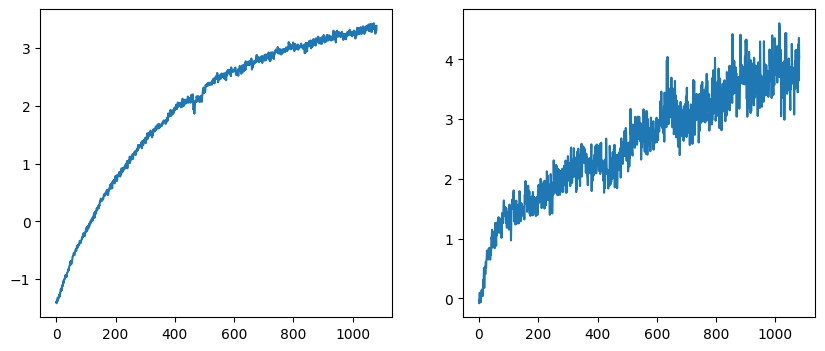

 11%|█         | 1088/10000 [39:13<5:21:18,  2.16s/it]


KeyboardInterrupt: 

In [9]:
for i in tqdm(range(10000)):
    # trajectory, info = collect_trajectories(env, model, n_steps=EPISODE_LENGTH)
    # shuffled_trajectory = shufffle_trajectory(trajectory)
    
    # ppo_optimization(shuffled_trajectory, model, optimizer, epochs=4, batch_size=1024)
    
    info = train_on_new_states(env, model, optimizer, None, num_policy_steps=EPISODE_LENGTH, target_model=None)
    
    avg_reward = info['trajectory']['rewards'].mean().item()
    
    reward_list.append(avg_reward)
    final_coords_list.append(info['trajectory']['states'].reshape(num_envs, EPISODE_LENGTH, 29)[:, -1, 0].mean().item())
    
    if i % 10 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        axs[0].plot(reward_list)
        axs[1].plot(final_coords_list)
        plt.plot()
        plt.show()
        # plt.savefig(f"tmp/antmaze_simple_test_with_z.png")

In [ ]:
env.close()

KeyboardInterrupt: 